<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/Early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [84]:
from sklearn.datasets import make_circles

In [85]:
X,y= make_circles(n_samples=100,noise=0.1,random_state=1)

In [86]:
X.shape

(100, 2)

In [87]:
y.shape

(100,)

In [88]:
import seaborn as sns

<Axes: >

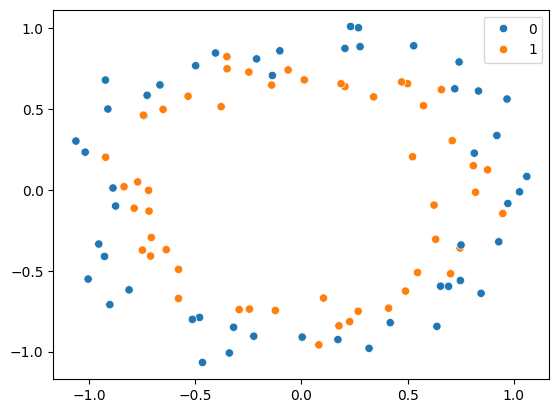

In [89]:
sns.scatterplot(x=X[:,0],y=X[:,-1],hue=y)

In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [91]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [92]:
model = Sequential()

model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [93]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [94]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
# history = model.fit(X_train,y_train,epochs=1000,validation_data=(X_test,y_test),verbose=0)

In [96]:
# plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
# plt.legend()
# plt.show()

In [97]:
from keras.callbacks import EarlyStopping
callbacks = EarlyStopping(
    monitor='val_loss',
    patience =100,
    mode = 'auto',
    restore_best_weights = True
)


In [98]:
model  = Sequential()

model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))


In [99]:

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [100]:
history = model.fit(X_train,y_train,epochs=1000,validation_data=(X_test,y_test),verbose=1,callbacks=callbacks)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step - accuracy: 0.5625 - loss: 0.6877 - val_accuracy: 0.3000 - val_loss: 0.7150
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5625 - loss: 0.6849 - val_accuracy: 0.3000 - val_loss: 0.7221
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5500 - loss: 0.6829 - val_accuracy: 0.3500 - val_loss: 0.7286
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5500 - loss: 0.6811 - val_accuracy: 0.3500 - val_loss: 0.7333
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5500 - loss: 0.6798 - val_accuracy: 0.3000 - val_loss: 0.7378
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5625 - loss: 0.6793 - val_accuracy: 0.3000 - val_loss: 0.7420
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5625 - loss: 0.6779 - val_accuracy: 0.3000 - val_loss: 0.7454
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6770 - val_accuracy: 0.3500 - 

/tmp/ipykernel_778/848098724.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


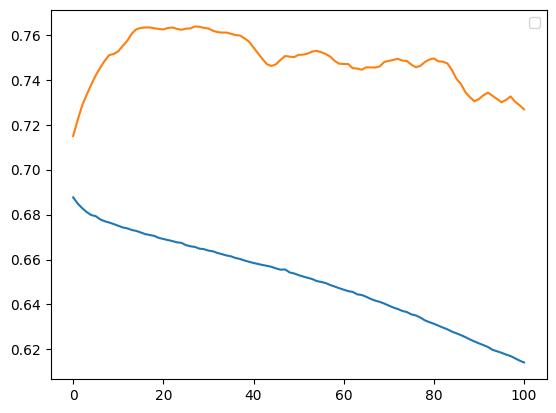

In [101]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend()
plt.show()